# Preview: memory-safe thumbnails of large rasters

When a raster is backed by dask (e.g. loaded lazily from Zarr or a stack of GeoTIFFs),
calling `.compute()` to visualize it can blow up your memory.  `xrspatial.preview()`
downsamples the data to a target pixel size using block averaging, and the whole
operation stays lazy until you ask for the result.  Peak memory is bounded by
the largest chunk plus the small output array.

This notebook creates a large dask array of random noise to demonstrate the
workflow.  A `dask.distributed` LocalCluster is started so you can watch the
task graph and worker memory in the dashboard.

In [1]:
import dask.array as da
import xarray as xr
import matplotlib.pyplot as plt

from xrspatial import preview

In [2]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster(n_workers=6, threads_per_worker=3, memory_limit="8GB")
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client

Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 15,Total memory: 37.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37481,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44283,Total threads: 3
Dashboard: http://127.0.0.1:33697/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:44375,


## Generate a large dask raster

Create a chunked array of random noise so the notebook runs anywhere without
external data files.

In [3]:
# 512 MB chunks of random noise
chunk = 11585
size = chunk * 48  # 556,080 x 556,080 ≈ 1.15 TB
big = xr.DataArray(
    da.random.random((size, size), chunks=(chunk, chunk)).astype("float32"),
    dims=["y", "x"],
)

print(f"Shape:      {big.shape[0]:,} x {big.shape[1]:,}")
print(f"Chunk size: {big.data.chunksize}")
print(f"Num chunks: {big.data.numblocks}")
print(f"Total size: {big.data.nbytes / 1e12:.2f} TB")
print(f"Dtype:      {big.dtype}")
big

Shape:      556,080 x 556,080
Chunk size: (11585, 11585)
Num chunks: (48, 48)
Total size: 1.24 TB
Dtype:      float32


<xarray.DataArray 'astype-9c03f090538d473740cb476d62a0a2a5' (y: 556080,
                                                             x: 556080)> Size: 1TB
dask.array<astype, shape=(556080, 556080), dtype=float32, chunksize=(11585, 11585), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x

## Preview at 1000x1000

`preview()` builds a lazy coarsen-then-mean graph.  Calling `.compute()` on the
result materializes only the 1000x1000 output -- about 4 MB.

In [4]:
%%time
small = preview(big, width=1000).compute()

print(f"Output shape: {small.shape}")
print(f"Output size:  {small.nbytes / 1e6:.1f} MB")

Output shape: (1000, 1000)
Output size:  4.0 MB
CPU times: user 1min 1s, sys: 6.61 s, total: 1min 8s
Wall time: 3min 39s


In [5]:
small

<xarray.DataArray 'preview' (y: 1000, x: 1000)> Size: 4MB
array([[0.50007755, 0.5003118 , 0.49893883, ..., 0.50008214, 0.49908373,
        0.49887007],
       [0.49942347, 0.5017593 , 0.49803457, ..., 0.5010285 , 0.50000775,
        0.5017164 ],
       [0.50130886, 0.49823362, 0.49976596, ..., 0.49946523, 0.49977544,
        0.49966756],
       ...,
       [0.50155383, 0.49993622, 0.49767074, ..., 0.50071174, 0.5005701 ,
        0.5008454 ],
       [0.5007478 , 0.4995752 , 0.50089383, ..., 0.50059164, 0.49913454,
        0.499114  ],
       [0.49991244, 0.4997942 , 0.50035053, ..., 0.50078255, 0.4994075 ,
        0.5005485 ]], shape=(1000, 1000), dtype=float32)
Dimensions without coordinates: y, x

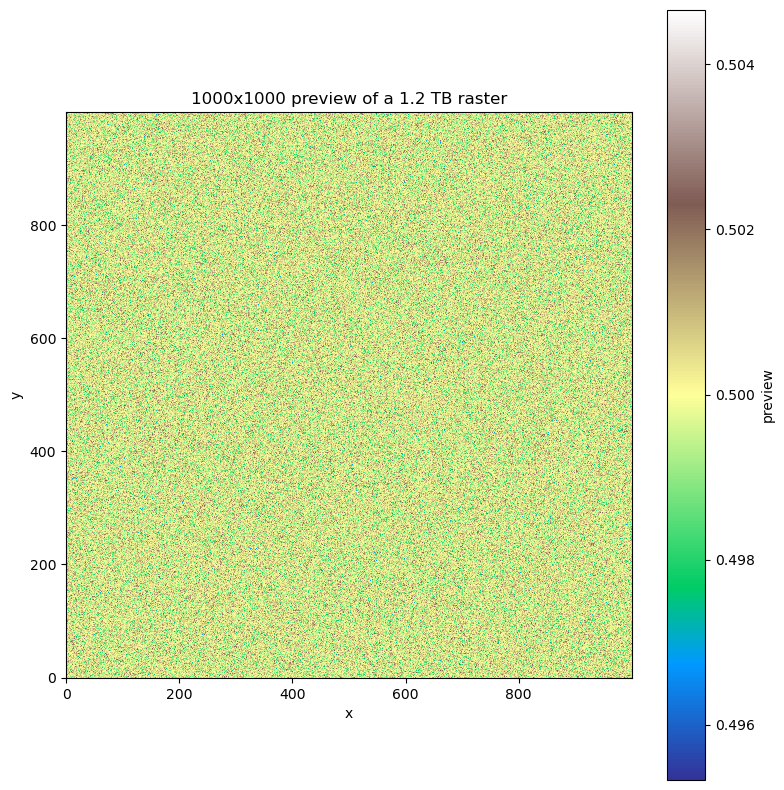

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
small.plot(ax=ax, cmap="terrain")
ax.set_title(f"1000x1000 preview of a {big.data.nbytes / 1e12:.1f} TB raster")
ax.set_aspect("equal")
plt.tight_layout()

## Accessor syntax

You can also call `preview` directly on a DataArray or Dataset via the `.xrs` accessor.

In [ ]:
client.close()
cluster.close()